<a href="https://colab.research.google.com/github/aleks-haksly/portfolio/blob/main/Marketing%20analytics/UNIT/unit_economics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
import ipywidgets as w

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import userdata
!pip install clickhouse_driver --quiet
from clickhouse_driver import Client

In [34]:
# connection requisites
host = 'clickhouse.lab.karpov.courses'
dbase = 'default'
port = 9000
user = 'student'
password = userdata.get('ch2020[student]')

In [35]:
client = Client(host=host, port=port, user=user,
                password=password, database=dbase)

# Расчет юнит экономики
## Выгрузка исходных данных
Разделим всех пользователей на когорты по месяцу первой покупки в нашем продукте,  после чего подготовим SQL запрос для ответа на следующие вопросы:
1. Как меняется число пользователей в каждой когорте со времением?
2. Сколько покупок совершили клиенты каждой когорты в каждый из месяцев?
3. Какой суммарный объем покупок совершили пользователи каждой когорты в каждом из месяцев?

In [36]:
sql = f"""
WITH purchases as (
SELECT c.UserID, toStartOfMonth(toDate(c.BuyDate)) AS buy_month, c.Rub, ch.cohort
FROM checks c
LEFT JOIN (SELECT UserID, toStartOfMonth(min(toDate(BuyDate))) AS cohort FROM checks GROUP BY UserID) ch
ON ch.UserID = c.UserID
WHERE buy_month < (SELECT max(toStartOfMonth(toDate(c.BuyDate))) FROM checks c) -- не будем учитывать последний неполный месяц
)
SELECT cohort, dateDiff('month', cohort, buy_month) as n_month, count(*) as purchases_cnt, uniq(UserID) as users_cnt, sum(Rub) as purchase_sum
FROM purchases p
GROUP BY cohort, n_month
"""
result, columns = client.execute(sql, with_column_types=True)
cohort_month_agg_data = pd.DataFrame(result, columns=[tuple[0] for tuple in columns])
cohort_month_agg_data.head()

,cohort,n_month,purchases_cnt,users_cnt,purchase_sum
0,2019-07-01,1,788909,144410,8757320
1,2019-02-01,1,972792,258292,9972424
2,2019-01-01,6,2523833,391547,28725448
3,2019-05-01,2,483302,86454,5166035
4,2019-02-01,2,571897,142002,6330292


### Число пользователей в когортах по месяцам от момента первой покупки

In [37]:
users_counts_pivot = pd.pivot(data=cohort_month_agg_data, index='cohort', columns='n_month', values='users_cnt')
users_counts_pivot.fillna("")

n_month,0,1,2,3,4,5,6,7,8
cohort,,,,,,,,,
2019-01-01,1526724.0,854370.0,657800.0,532745.0,472310.0,425317.0,391547.0,376701.0,372591.0
2019-02-01,632868.0,258292.0,142002.0,101753.0,82465.0,72764.0,69380.0,68857.0,
2019-03-01,561838.0,224028.0,122977.0,85821.0,71307.0,66230.0,63613.0,,
2019-04-01,571983.0,208141.0,111330.0,81355.0,70400.0,65517.0,,,
2019-05-01,368801.0,146781.0,86454.0,66828.0,58709.0,,,,
2019-06-01,384977.0,144335.0,86987.0,66578.0,,,,,
2019-07-01,357110.0,144410.0,87134.0,,,,,,
2019-08-01,408375.0,169704.0,,,,,,,
2019-09-01,317574.0,,,,,,,,


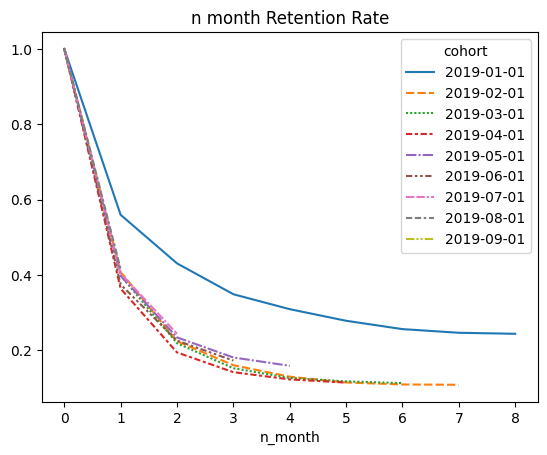

In [50]:
# Посмотрим на n month retantion rate в когортах
sns.lineplot(users_counts_pivot.apply(lambda x: x/x[0], axis=1).T).set_title("n month Retention Rate");

#### Промежуточный анализ
На данном этапе анализа мы видим, что число новых пользвателй продукта имеет тенденцию к снижению от месяца к месяцу. Это могло бы быть связано с внутригодовой сезонностью летних месяцев, но мы видим, что и в 9 месяце восстановления притока новых пользователей не происходит.
В любом случае стоит провести анализ и выявить причины. Вот несколько возможных факторов и решений:

1. Проверить технические проблемы
* Долго ли загружается сайт/приложение?
* Есть ли баги или проблемы с регистрацией?

2. Анализировать воронку привлечения пользователей:
* Как изменились источники трафика (SEO, реклама, реферальные каналы)?
* Есть ли проблемы с конверсией на сайте или в приложении?

`Возможно, нужно провести аудит маркетинговых каналов, A/B-тестирование лендингов, улучшить Onboarding.`

3. Оценить изменение целевой аудитории
* Насколько все еще актуален продукт для текущей аудитории?
* Есть ли перенасыщение рынка или уход конкурентов?

`Пересмотреть позиционирование, протестировать новые сегменты аудитории.`

4. Проверить продуктовые метрики и фидбэк пользователей
* Упала ли активность пользователей (DAU, MAU, Retention)?
* Есть ли негативные отзывы, которые могут отталкивать новых клиентов?

`Улучшить UX, добавить фичи, которые просят пользователи, запустить программу лояльности.`

5. Оценить влияние внешних факторов
* Есть ли сезонность в продукте?
* Влияют ли экономические факторы (кризис, снижение спроса)?

`Скорректировать стратегию продвижения с учетом макрофакторов.`


Что касаетеся падения количества пользователей в каждой когорте со временем (chorn rate), то здесь нужно попытаться сделать рекативацию старых клиентов, чтобы вернуть их в продукт.

1. Анализ ушедших клиентов и причин оттока
Сегментация пользователей:

* "Спящие" клиенты (неактивны 30/60/90+ дней).
*  Клиенты с редкими покупками (раз в несколько месяцев).
* Клиенты, которые отказались от продукта.
* Поиск причин оттока:

Что они покупали раньше?
Почему перестали? (повышение цен, плохой сервис, ушли к конкуренту)
Были ли проблемы с доставкой, качеством, удобством заказа?
*  Данные можно получить через аналитику (когортный анализ, RFM) или опросы.

2. Email, push-уведомления, SMS: персональные триггерные кампании
Стратегия реактивации:
* "Мы вас не видели уже X дней!" – персонализированное сообщение с выгодным предложением.
* "Вот что вы покупали – хотите повторить?" – напоминание о предыдущих покупках с быстрым повторным заказом.
* "Скидка -20% на ваш любимый товар!" – эксклюзивное предложение для возврата.
* "Мы улучшились! Вот что нового в продукте" – обновления, которые могли заинтересовать ушедших клиентов.

Здесь также есть место для AB тестов:
* Какие сообщения работают лучше?
* Какая скидка / акция наиболее эффективна?

3. Специальные офферы для "спящих" клиентов
*  Персональные скидки – ограниченные во времени («только 48 часов!»).
*  Подарки за возвращение – бонус на первую покупку после долгого перерыва.
* Кэшбэк / бесплатная доставка – снижает барьер возврата.
* "Приведи друга – получите бонус оба" – дополнительный стимул.

4. Ретаргетинг и ремаркетинг
* Таргетированная реклама (Facebook, Instagram, Google Ads) на тех, кто заходил в продукт, но давно не покупал.
* Персонализированные баннеры и рекомендации на сайте.
* Push-уведомления в приложении, если клиент заходил, но не сделал заказ.

5. Улучшение пользовательского опыта (UX) и работы с возражениями
* Анализ проблем UX/UI – удобство навигации, скорости загрузки, способов оплаты.
* Оптимизация доставки – новые удобные способы получения заказов.
* Уведомления о новинках и акциях – показывать ценность продукта.
* Обратная связь – спросить у клиентов, чего им не хватало, и устранить проблемы.

Ключевыми метриками для оценки реактивации будут:
* Retention rate (удержание пользователей после реактивации)
* % вернувшихся клиентов после акции
* Средний чек реактивированных пользователей
* Время до повторного заказа после реактивации

Кроме того из графика n month RR видно, что никаких улучшений в продукте в плане удердания пользователей с течением времени не наблюдается, за исключением 5 месяца. Что происходило в 5 месяце требует дополнительного изучения.

Для повышения RR могут применятьс следующие стратегии:

1. Улучшение первого опыта (First-Time User Experience, FTUE)
* Гладкий онбординг → обучение через интерактивные подсказки, видео.
* Быстрое достижение первой ценности → минимальный путь до результата.
* Геймификация → прогресс-бары, награды за первые действия.

Пример:
* Netflix рекомендует лучшие фильмы сразу после регистрации.
* Доставка еды предлагает скидку на первый заказ.

2. Регулярные триггеры и напоминания
* Персонализированные пуш-уведомления → напоминания о незавершённых действиях.
* E-mail / мессенджер маркетинг → полезные рассылки, триггерные цепочки.
* Календарные напоминания → особенно для подписок и регулярных покупок.

Пример:
* Аптека отправляет напоминание «Заканчиваются витамины? Пора пополнить запасы!».
* Фитнес-приложение напоминает: «Вы не тренировались 3 дня, возвращайтесь!».

3. Лояльность, бонусы и подписки
*  Бонусная система → кешбэк, скидки за повторные покупки.
* VIP-программы → эксклюзивные предложения для постоянных клиентов.
* Подписки на регулярные товары → аптечные, продуктовые, косметические.

Пример:
* Ozon Premium → бесплатная доставка и бонусы для подписчиков.
* Sephora Beauty Insider → баллы за покупки, доступ к VIP-товарам.

4. Персонализация контента и рекомендаций
* Рекомендации на основе истории покупок.
* Персонализированные подборки и предложения.
* Интерактивные опросы и сбор обратной связи.

Пример:
* Spotify подбирает плейлисты на основе предпочтений.
* Amazon предлагает «Вам может понравиться…» на основе истории заказов.

5. Геймификация и социальные элементы
* Система уровней и достижений → клиенты получают статус за активность.
* Реферальные программы → бонус за приглашение друзей.
* Чаты, форумы, комьюнити → обсуждения, пользовательский контент.

Пример:
* Duolingo → «Серия дней без пропусков» для мотивации учить язык.
* AliExpress → «Заработайте купон за ежедневные входы».

6. Работа с негативом и churn
* Выявление причин оттока (churn analysis) → аналитика поведения ушедших клиентов.
* Опросы при уходе → предложение скидки или персонального предложения.
* Реактивационные кампании → «Мы вас давно не видели! Вернитесь и получите 10% скидки».

Пример:
* Отписываешься от Netflix? Они предлагают скидку на 1 месяц.
* Slack при удалении аккаунта спрашивает, что можно улучшить.





### Число покупок в когортах по месяцам от момента первой покупки

In [42]:
purchase_count_pivot = pd.pivot(data=cohort_month_agg_data, index='cohort', columns='n_month', values='purchases_cnt')
purchase_count_pivot.fillna("")

n_month,0,1,2,3,4,5,6,7,8
cohort,,,,,,,,,
2019-01-01,6561523.0,4387259.0,3642276.0,3033845.0,3003361.0,2646199.0,2523833.0,2531305.0,2541385.0
2019-02-01,1451953.0,972792.0,571897.0,478251.0,391710.0,367392.0,366786.0,372523.0,
2019-03-01,1337461.0,924573.0,617474.0,431662.0,380689.0,372596.0,367538.0,,
2019-04-01,1402514.0,1000594.0,568107.0,444699.0,411435.0,390045.0,,,
2019-05-01,956576.0,707593.0,483302.0,397010.0,356397.0,,,,
2019-06-01,966668.0,745575.0,524018.0,415806.0,,,,,
2019-07-01,911558.0,788909.0,542966.0,,,,,,
2019-08-01,1121320.0,986329.0,,,,,,,
2019-09-01,880700.0,,,,,,,,


### Сумма продаж в когортах по месяцам от момента первой покупки

In [47]:
purchases_sum_pivot = pd.pivot(data=cohort_month_agg_data, index='cohort', columns='n_month', values='purchase_sum')
purchases_sum_pivot.fillna("")

n_month,0,1,2,3,4,5,6,7,8
cohort,,,,,,,,,
2019-01-01,68829322.0,49409579.0,41757635.0,36869934.0,33928616.0,30489913.0,28725448.0,29905002.0,29861977.0
2019-02-01,14274340.0,9972424.0,6330292.0,5090178.0,4334399.0,4056235.0,4230959.0,4246048.0,
2019-03-01,12587199.0,9392577.0,6414580.0,4726519.0,4158797.0,4296210.0,4153242.0,,
2019-04-01,13148754.0,9952484.0,6042636.0,4788633.0,4616932.0,4417100.0,,,
2019-05-01,8978133.0,7252867.0,5166035.0,4391236.0,3926504.0,,,,
2019-06-01,9463821.0,7852239.0,5791151.0,4550280.0,,,,,
2019-07-01,8962814.0,8757320.0,5962075.0,,,,,,
2019-08-01,11682310.0,10383980.0,,,,,,,
2019-09-01,8856254.0,,,,,,,,


Число и сумма покупок также пропорционально упали, что логично, так как пользователей стало меньше

In [60]:
# Сумма продаж накопительным итогом
purchases_sum_pivot.cumsum(axis=1).fillna("")

n_month,0,1,2,3,4,5,6,7,8
cohort,,,,,,,,,
2019-01-01,68829322.0,118238901.0,159996536.0,196866470.0,230795086.0,261284999.0,290010447.0,319915449.0,349777426.0
2019-02-01,14274340.0,24246764.0,30577056.0,35667234.0,40001633.0,44057868.0,48288827.0,52534875.0,
2019-03-01,12587199.0,21979776.0,28394356.0,33120875.0,37279672.0,41575882.0,45729124.0,,
2019-04-01,13148754.0,23101238.0,29143874.0,33932507.0,38549439.0,42966539.0,,,
2019-05-01,8978133.0,16231000.0,21397035.0,25788271.0,29714775.0,,,,
2019-06-01,9463821.0,17316060.0,23107211.0,27657491.0,,,,,
2019-07-01,8962814.0,17720134.0,23682209.0,,,,,,
2019-08-01,11682310.0,22066290.0,,,,,,,
2019-09-01,8856254.0,,,,,,,,


## Теперь посчитаем удельные значения:
### Число покупок на пользователя в когортах

In [52]:
orders_per_client = purchase_count_pivot.div(users_counts_pivot.values, axis=0)
orders_per_client.fillna("")

n_month,0,1,2,3,4,5,6,7,8
cohort,,,,,,,,,
2019-01-01,4.297779,5.135081,5.537057,5.694741,6.358877,6.22171,6.445798,6.719666,6.820844
2019-02-01,2.294243,3.766249,4.027387,4.700117,4.750015,5.04909,5.286624,5.410096,
2019-03-01,2.380510,4.127042,5.021053,5.029795,5.338733,5.625789,5.777718,,
2019-04-01,2.452020,4.807289,5.10291,5.466155,5.844247,5.95334,,,
2019-05-01,2.593746,4.82074,5.590279,5.940773,6.070568,,,,
2019-06-01,2.510976,5.165587,6.024096,6.245396,,,,,
2019-07-01,2.552597,5.46298,6.231391,,,,,,
2019-08-01,2.745810,5.812055,,,,,,,
2019-09-01,2.773212,,,,,,,,


Text(0.5, 1.0, 'Число покупок на пользователя по месяцам от момента первой покупки')

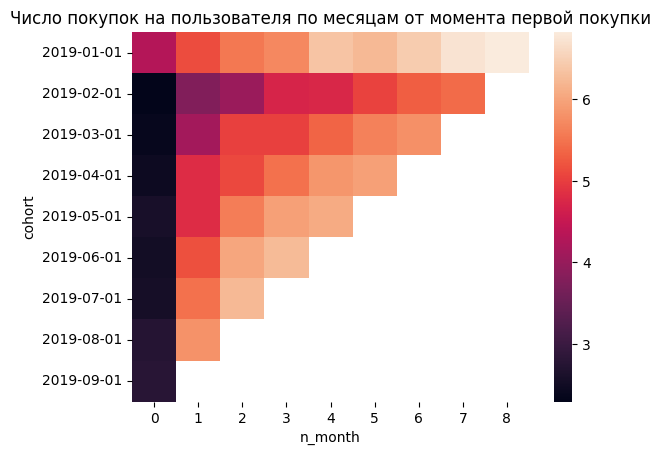

In [53]:
sns.heatmap(orders_per_client).set_title("Число покупок на пользователя по месяцам от момента первой покупки")

 Сильный рост внутри каждой когорты, по-видимому, обусловлен скорее тем, что менее активные и менее заинтересованные в продукте пользователи постепенно вымываются с оттоком. При этом среднее число покупок на пользователя растет со временем в от когорты к когорте.  Также видим, что наш бизнес частотный, что нам необходимо прикладывать усилия для удержания пользователя в продукте. Дополнительно, чтобы еще увеличить число повторных покупок, можно сосредоточиться на следующих аспектах:

1. Улучшение пользовательского опыта (UX)
* Оптимизация интерфейса: удобный процесс оформления заказа, быстрый доступ к истории покупок, понятная навигация.
* Персонализация: рекомендации товаров на основе истории покупок, предпочтений и поведения пользователя.
2. Программы лояльности и скидки
* Бонусные баллы за каждую покупку, которые можно потратить на скидки.
* Кэшбэк за частые заказы.
* Персонализированные скидки для сегментов пользователей (например, если клиент давно не заказывал).
3. Триггерные и ремаркетинговые кампании
* Email / push-уведомления с напоминанием о повторном заказе.
* Скидки или спецпредложения на товары, которые клиент покупал ранее.
* Автоматические рекомендации товаров, которые заканчиваются (например, лекарства, косметика, товары первой необходимости).
4. Расширение ассортимента и кросс-продажи
* Комбинированные предложения (например, «Купите X и получите Y со скидкой»).
* Апсейл: предлагать премиальные версии продуктов.
* Подписки на регулярные поставки товаров.
6. Уменьшение причин отказов
* Оптимизация доставки (более быстрые и удобные способы получения).
* Упрощение возвратов (чтобы клиент не боялся ошибиться с заказом).
* Повышение доверия (отзывы, гарантии качества).

### Теперь посмотрим на средний чек по месяцам в каждой когорте (ARPPU)

In [54]:
avg_per_purchase = purchases_sum_pivot.div(users_counts_pivot.values, axis=0)
avg_per_purchase.fillna("")

n_month,0,1,2,3,4,5,6,7,8
cohort,,,,,,,,,
2019-01-01,45.083016,57.831594,63.480746,69.207471,71.835481,71.687501,73.363984,79.386574,80.146802
2019-02-01,22.555004,38.609109,44.578893,50.024844,52.560468,55.74508,60.982401,61.664725,
2019-03-01,22.403609,41.925907,52.160811,55.074154,58.322423,64.868036,65.289202,,
2019-04-01,22.988015,47.816067,54.276799,58.860955,65.58142,67.419143,,,
2019-05-01,24.344112,49.412846,59.754725,65.709523,66.880785,,,,
2019-06-01,24.582822,54.402875,66.574902,68.345099,,,,,
2019-07-01,25.098188,60.642061,68.424209,,,,,,
2019-08-01,28.606820,61.188776,,,,,,,
2019-09-01,27.887214,,,,,,,,


Видим, что средний чек также растет во всех когортах с каждым месяцем, что говорит нам о том, что мы эффективно работаем со стрыми клиентами. При необходимости еще увеличить средний чек на клиента, можно делать:
1. Апселл (Upsell) — продажа более дорогих товаров
* Рекомендация премиальных версий: показывать клиенту более дорогие аналоги выбранного товара.
* Пакеты и расширенные версии: продавать «расширенные» комплекты с дополнительными функциями.
* Оптимизация фильтров и сортировки: по умолчанию предлагать товары с более высокой ценой или выгодные пакеты.

Пример:
* Вместо обычного крема для лица предлагать клиенту профессиональную серию с более высоким ценником.

2. Кросс-селл (Cross-sell) — допродажа сопутствующих товаров
* Рекомендации товаров-компаньонов (например, аксессуары, доп. услуги).
* Готовые наборы (например, «Купите смартфон + чехол + защитное стекло»).
* Алгоритмы рекомендаций: «С этим товаром часто покупают...».

Пример:
* Клиент покупает шампунь → предложить кондиционер и маску для волос.

3. Минимальный порог для скидки или бонуса
* «Доставка бесплатно при заказе от X» → клиент добирает сумму.
* «Скидка 10% при заказе от Y рублей».
* Бонусная система: «Купите ещё на 500 ₽ и получите 100 бонусов».

Пример:
* Доставка бесплатно от 2000 ₽ → клиент добавит что-то ещё в корзину.

4. Подписки и пакеты (Subscription & Bundles)
* Подписка на регулярные поставки товаров (например, лекарства, еда, косметика).
* Программы годового обслуживания (например, Amazon Prime, Ozon Premium).
* Эксклюзивные наборы с ограниченным тиражом.

5. Лимитированные предложения и триггерные акции
* «Осталось X штук!» → стимулирует покупку.
* «Акция: добавь ещё один товар и получи скидку».
* Персональные предложения для VIP-клиентов.

6. Психология ценообразования
* Окончание цены на 9 (1999₽ вместо 2000₽).
* Якорные цены (рядом с дорогим товаром дешевый кажется выгодным).
* Комбо-цены (набор стоит дешевле, чем сумма товаров по отдельности).

## Рассчитаем, сколько нам приносит в cреднем один пользователь в каждой когорте (ARPPU)

In [64]:
arrppu = orders_per_client.mul(avg_per_purchase, axis=0)
arrppu.fillna("")

n_month,0,1,2,3,4,5,6,7,8
cohort,,,,,,,,,
2019-01-01,193.756857,296.969909,351.496502,394.118648,456.792958,446.018838,472.889448,533.451286,546.668813
2019-02-01,51.746660,145.41152,179.536452,235.122619,249.66302,281.461938,322.39105,333.612102,
2019-03-01,53.332017,173.029984,261.90218,277.011683,311.367815,364.933876,377.222623,,
2019-04-01,56.367083,229.865667,276.969633,321.743075,383.27403,401.369105,,,
2019-05-01,63.142436,238.206472,334.045598,390.365381,406.004379,,,,
2019-06-01,61.726875,281.022785,401.053571,426.842234,,,,,
2019-07-01,64.065566,331.28639,426.37798,,,,,,
2019-08-01,78.548881,355.632537,,,,,,,
2019-09-01,77.337153,,,,,,,,


In [89]:
# ARPPU накопительным итогом
arrppu_cumsum = arrppu.cumsum(axis=1)
arrppu_cumsum.fillna("")

n_month,0,1,2,3,4,5,6,7,8
cohort,,,,,,,,,
2019-01-01,193.756857,490.726767,842.223269,1236.341917,1693.134874,2139.153713,2612.043161,3145.494447,3692.16326
2019-02-01,51.746660,197.15818,376.694633,611.817252,861.480272,1142.94221,1465.333259,1798.945362,
2019-03-01,53.332017,226.362001,488.26418,765.275863,1076.643678,1441.577554,1818.800176,,
2019-04-01,56.367083,286.23275,563.202383,884.945458,1268.219488,1669.588594,,,
2019-05-01,63.142436,301.348908,635.394506,1025.759888,1431.764267,,,,
2019-06-01,61.726875,342.74966,743.803232,1170.645465,,,,,
2019-07-01,64.065566,395.351956,821.729936,,,,,,
2019-08-01,78.548881,434.181417,,,,,,,
2019-09-01,77.337153,,,,,,,,


<Axes: xlabel='n_month', ylabel='cohort'>

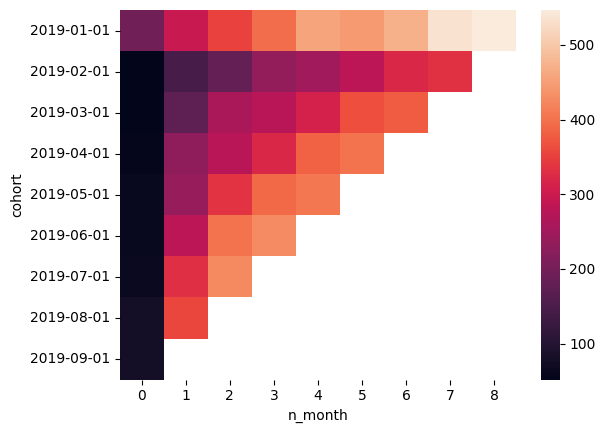

In [66]:
sns.heatmap(arrppu)

Низкий ARPPU в первый месяц скорее всего обусловлен тем, что в продукте для новых пользователей есть какая-то скидка или бесплатный период. Но с учетом низкого числа покупок в первый месяц - это скорее всего бесплатный период.

## COGS по когортам

В данном случае у нас нет данных, какую часть от продажной стоимости наших продуктов составляет себестоимость, поэтому сделаем предположение, что она около 50% и не менятся со временим

In [79]:
cogs_ratio = w.FloatSlider(value=0.5, min=0.01, max=0.99, step=0.01, description="Доля себестоимоси продукции")
cogs_ratio

FloatSlider(value=0.5, description='Доля себестоимоси продукции', max=0.99, min=0.01, step=0.01)

In [104]:
@w.interact(cogs_ratio=(0.01, 0.99, 0.01))
def ltv(cogs_ratio):
  print("LTV по когортам")
  return arrppu_cumsum.mul(1.0 - cogs_ratio).fillna("")

interactive(children=(FloatSlider(value=0.5, description='cogs_ratio', max=0.99, min=0.01, step=0.01), Output(…

In [116]:
!pip install pytubefix -q

from pytubefix import YouTube
from pytubefix.cli import on_progress

url = "https://www.youtube.com/watch?v=oofRb9tLcQ4"

yt = YouTube(url, on_progress_callback = on_progress)
print(yt.title)

ys = yt.streams.get_audio_only()
ys.download()

Кумулятивные эффекты. Проблема Exploration Exploitation


'/content/Кумулятивные эффекты. Проблема Exploration Exploitation.m4a'